In [1]:
import rustworkx as rx
import matplotlib.pyplot as plt
import numpy as np
from tn4qa.quantum_algorithms.hamiltonian_simulation.qdrift import QDriftSimulation
from nbed.ham_builder import HamiltonianBuilder
import pyscf
import qiskit.qasm2
import json

from ferrmion.hamiltonians import molecular_hamiltonian
from ferrmion.utils import fermionic_to_sparse_majorana
from ferrmion.encode import JordanWigner, ParityEncoding, BravyiKitaev, JKMN
from ferrmion.optimize.bonsai import bonsai_algorithm
from ferrmion.optimize.topphatt import topphatt

In [2]:
garnet_edges = [
    (1, 0),
    (1, 4),
    (3, 0),
    (3, 2),
    (3, 4),
    (3, 8),
    (5, 4),
    (5, 6),
    (5, 10),
    (7, 2),
    (7, 8),
    (7, 12),
    (9, 4),
    (9, 8),
    (9, 10),
    (9, 14),
    (11, 6),
    (11, 10),
    (11, 16),
    (13, 8),
    (13, 12),
    (13, 14),
    (13, 17),
    (15, 10),
    (15, 14),
    (15, 16),
    (15, 19),
    (18, 14),
    (18, 17),
    (18, 19)
]

In [3]:
def make_ham_real(hamiltonian: dict[str, complex]) -> dict[str, float]:
    real_ham = {}
    for item in hamiltonian:
        real_ham[item] = np.real(hamiltonian[item])
    return real_ham

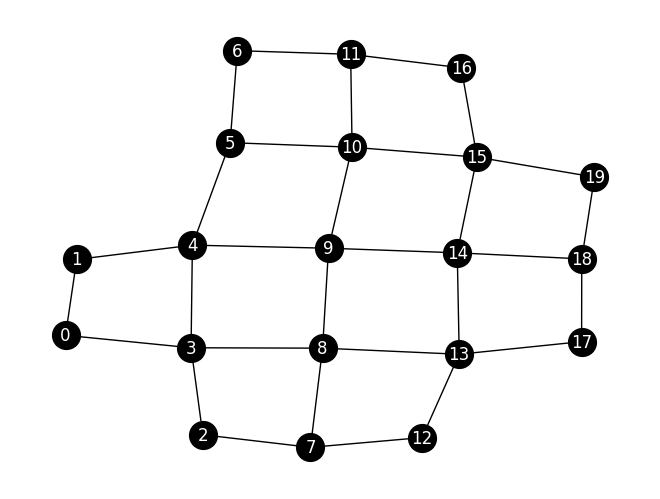

In [4]:
#rustworkx graph from edges (the actual input for bonsai)

garnet_graph_rx = rx.PyGraph()
num_qubits = max(max(pair) for pair in garnet_edges) + 1
garnet_graph_rx.add_nodes_from(range(num_qubits))
garnet_graph_rx.add_edges_from_no_data(garnet_edges)

rx.visualization.mpl_draw(
    graph = garnet_graph_rx, 
    with_labels = True,
    node_color = 'black',
    node_size = 400,
    font_color = 'white',
    pos = rx.spring_layout(garnet_graph_rx, seed=5)
)

In [5]:
mol_obj = pyscf.M(
    atom = 'mols/H2O.xyz',
    basis = 'sto-3g'
)

print('qubits =', mol_obj.nao*2)

qubits = 14


In [6]:
rhf_obj = pyscf.scf.RHF(mol_obj).run()

converged SCF energy = -74.9659011922597


In [7]:
e_nuc, one_e_coeffs, two_e_coeffs = HamiltonianBuilder(
    scf_method=rhf_obj,
    constant_e_shift=mol_obj.energy_nuc()
).build()

In [8]:
def get_hams(encoding_tree, one_e_coeffs, two_e_coeffs, e_nuc):
    ham = molecular_hamiltonian(
        encoding = encoding_tree, 
        one_e_coeffs = one_e_coeffs, 
        two_e_coeffs = two_e_coeffs, 
        constant_energy = e_nuc
    )
    tophatt_tree = topphatt(
        majorana_ham = fermionic_to_sparse_majorana(((one_e_coeffs,"+-"), (two_e_coeffs, "++--"))),
        tree = encoding_tree
    )
    tophatt_ham = molecular_hamiltonian(
        encoding = tophatt_tree, 
        one_e_coeffs = one_e_coeffs, 
        two_e_coeffs = two_e_coeffs, 
        constant_energy = e_nuc
    )
    ham = make_ham_real(ham)
    tophatt_ham = make_ham_real(tophatt_ham)
    return (ham, tophatt_ham)

In [9]:
bonsai_garnet_truncated = bonsai_algorithm(
    graph = garnet_graph_rx,
    homogenous = False,
    max_nodes = 14
)

In [10]:
bonsai_hams = get_hams(
    encoding_tree = bonsai_garnet_truncated,
    one_e_coeffs = one_e_coeffs,
    two_e_coeffs = two_e_coeffs,
    e_nuc = e_nuc
)

In [11]:
jw_hams = get_hams(
    encoding_tree = JordanWigner(one_e_coeffs.shape[0]),
    one_e_coeffs = one_e_coeffs,
    two_e_coeffs = two_e_coeffs,
    e_nuc = e_nuc
)

In [12]:
bk_hams = get_hams(
    encoding_tree = BravyiKitaev(one_e_coeffs.shape[0]),
    one_e_coeffs = one_e_coeffs,
    two_e_coeffs = two_e_coeffs,
    e_nuc = e_nuc
)

In [13]:
parity_hams = get_hams(
    encoding_tree = ParityEncoding(one_e_coeffs.shape[0]),
    one_e_coeffs = one_e_coeffs,
    two_e_coeffs = two_e_coeffs,
    e_nuc = e_nuc
)

In [14]:
jkmn_hams = get_hams(
    encoding_tree = JKMN(one_e_coeffs.shape[0]),
    one_e_coeffs = one_e_coeffs,
    two_e_coeffs = two_e_coeffs,
    e_nuc = e_nuc
)

In [15]:
def run_qdrift(hams, duration):
    qdrift = QDriftSimulation(
        hamiltonian = hams[0],
        duration = duration
    )
    naive_depth = qdrift.circuit.depth()

    qdrift = QDriftSimulation(
        hamiltonian = hams[1],
        duration = duration
    )
    tophatt_depth = qdrift.circuit.depth()

    return (naive_depth, tophatt_depth)

In [16]:
results = {
    "bonsai" : {
        "hams" : bonsai_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
    "JW" : {
        "hams" : jw_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
    "BK" : {
        "hams" : bk_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
    "parity" : {
        "hams" : parity_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
    "JKMN" : {
        "hams" : jkmn_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
}

In [17]:
dur = 0.001
repeats = 1000

for _ in range(repeats):
    for encoding, data in results.items():
        naive_depth, tophatt_depth = run_qdrift(data["hams"], dur)
        data["naive"].append(naive_depth)
        data["topphatt"].append(tophatt_depth)

In [18]:
with open("untranspiled_results.json", 'w') as f:
    json.dump(results, f)

In [2]:
with open("untranspiled_results.json", 'r') as f:
    results = json.load(f)

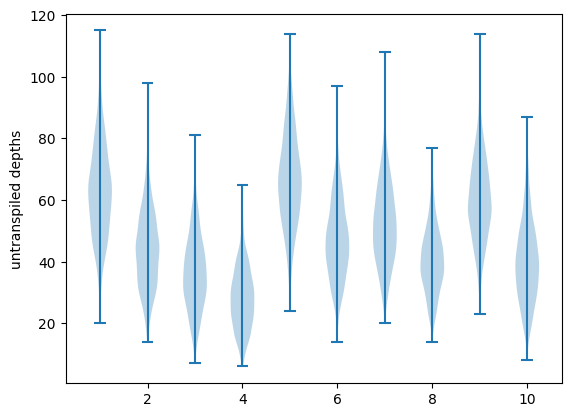

In [3]:
plt.violinplot([
    results["bonsai"]["naive"],
    results["bonsai"]["topphatt"],
    results["JW"]["naive"],
    results["JW"]["topphatt"],
    results["BK"]["naive"],
    results["BK"]["topphatt"],
    results["parity"]["naive"],
    results["parity"]["topphatt"],
    results["JKMN"]["naive"],
    results["JKMN"]["topphatt"],
])

plt.ylabel('untranspiled depths')

plt.show()

In [4]:
for encoding, data in results.items():
    print(encoding)

bonsai
JW
BK
parity
JKMN


In [5]:
order = ["JW", "JKMN", "parity", "bonsai", "BK"]


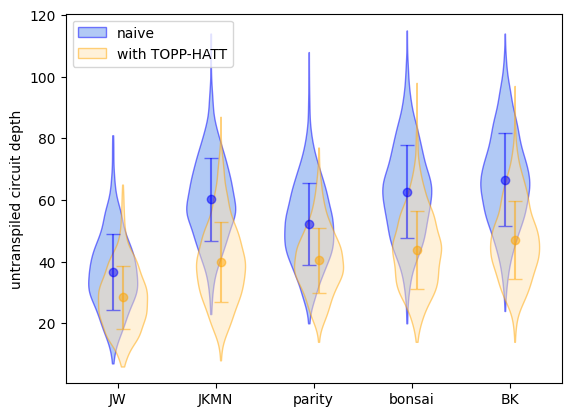

In [8]:
spacing = 0.05

naive_data   = [results[name]["naive"] for name in order]
tophatt_data = [results[name]["topphatt"]    for name in order]

positions_naive   = [i + 1 - spacing for i in range(len(order))]
positions_tophatt = [i + 1 + spacing for i in range(len(order))]

plt.tight_layout()

naive_violin = plt.violinplot(
    dataset=naive_data,
    positions=positions_naive,
)
tophatt_violin = plt.violinplot(
    dataset=tophatt_data,
    positions=positions_tophatt,
)

alpha = 0.5
naive_edge = 'blue'
naive_fill = 'cornflowerblue'
tophatt_edge = 'orange'
tophatt_fill = 'moccasin'

for i, body in enumerate(naive_violin['bodies']):
    body.set_facecolor(naive_fill)
    body.set_edgecolor(naive_edge)
    body.set_alpha(alpha)

naive_violin['bodies'][0].set_label("naive")

for i, body in enumerate(tophatt_violin['bodies']):
    body.set_facecolor(tophatt_fill)
    body.set_edgecolor(tophatt_edge)
    body.set_alpha(alpha)

tophatt_violin['bodies'][0].set_label("with TOPP-HATT")


for key in ["cbars", "cmaxes", "cmins"]:
    naive_violin[key].set_color("none")
    tophatt_violin[key].set_color("none")

for i, name in enumerate(order):
    x_naive = positions_naive[i]
    x_topphatt = positions_tophatt[i]

    y_naive = np.mean(results[name]["naive"])
    e_naive = np.std(results[name]["naive"])

    y_topphatt = np.mean(results[name]["topphatt"])
    e_topphatt = np.std(results[name]["topphatt"])

    plt.errorbar(x=x_naive, y=y_naive,
                 yerr=e_naive, fmt='o', color=naive_edge,
                 capsize=5, alpha=alpha)

    plt.errorbar(x=x_topphatt, y=y_topphatt,
                 yerr=e_topphatt, fmt='o', color=tophatt_edge,
                 capsize=5, alpha=alpha)

plt.legend(loc="upper left")
plt.xticks([i + 1 for i in range(len(order))], order)
plt.ylabel("untranspiled circuit depth")

plt.savefig("untranspiled_qdrift.pdf")

plt.show()

In [24]:
for encoding in results.keys():
    data = results[encoding]
    hams = data["hams"]

    for variant, ham in zip(["naive", "topphatt"], hams):
        
        target_depth = int(np.mean(data[variant]))

        while True:
            qdrift = QDriftSimulation(hamiltonian=ham, duration=dur)

            if qdrift.circuit.depth() == target_depth:
                results[encoding][f"{variant}_mean_depth"] = target_depth
                results[encoding][f"{variant}_mean_qasm"] = qiskit.qasm2.dumps(qdrift.circuit)
                print(f"done {encoding} {variant} {target_depth}")
                break

done bonsai naive 62
done bonsai topphatt 43
done JW naive 36
done JW topphatt 28
done BK naive 66
done BK topphatt 47
done parity naive 52
done parity topphatt 40
done JKMN naive 60
done JKMN topphatt 39


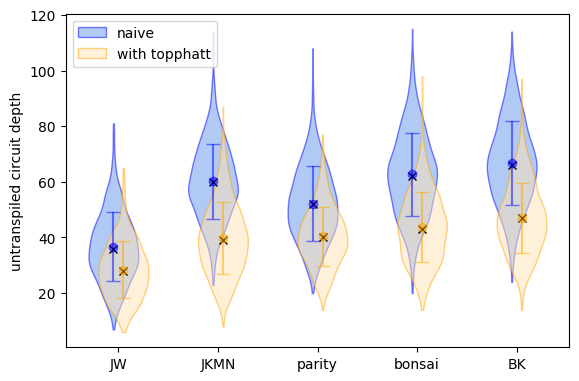

In [25]:
spacing = 0.05

naive_data   = [results[name]["naive"] for name in order]
tophatt_data = [results[name]["topphatt"]    for name in order]

positions_naive   = [i + 1 - spacing for i in range(len(order))]
positions_tophatt = [i + 1 + spacing for i in range(len(order))]

plt.figure(figsize=(468/72, (468*(2/3))/72))
plt.tight_layout()

naive_violin = plt.violinplot(
    dataset=naive_data,
    positions=positions_naive,
)
tophatt_violin = plt.violinplot(
    dataset=tophatt_data,
    positions=positions_tophatt,
)

alpha = 0.5
naive_edge = 'blue'
naive_fill = 'cornflowerblue'
tophatt_edge = 'orange'
tophatt_fill = 'moccasin'

for i, body in enumerate(naive_violin['bodies']):
    body.set_facecolor(naive_fill)
    body.set_edgecolor(naive_edge)
    body.set_alpha(alpha)

naive_violin['bodies'][0].set_label("naive")

for i, body in enumerate(tophatt_violin['bodies']):
    body.set_facecolor(tophatt_fill)
    body.set_edgecolor(tophatt_edge)
    body.set_alpha(alpha)

tophatt_violin['bodies'][0].set_label("with topphatt")


for key in ["cbars", "cmaxes", "cmins"]:
    naive_violin[key].set_color("none")
    tophatt_violin[key].set_color("none")

for i, name in enumerate(order):
    x_naive = positions_naive[i]
    x_topphatt = positions_tophatt[i]

    y_naive = np.mean(results[name]["naive"])
    e_naive = np.std(results[name]["naive"])

    y_topphatt = np.mean(results[name]["topphatt"])
    e_topphatt = np.std(results[name]["topphatt"])

    depth_naive = results[name]["naive_mean_depth"]
    depth_topphatt = results[name]["topphatt_mean_depth"]

    plt.errorbar(x=x_naive, y=y_naive,
                 yerr=e_naive, fmt='o', color=naive_edge,
                 capsize=5, alpha=alpha)

    plt.errorbar(x=x_topphatt, y=y_topphatt,
                 yerr=e_topphatt, fmt='o', color=tophatt_edge,
                 capsize=5, alpha=alpha)
    
    plt.plot(x_naive, depth_naive, 'x', color='black')
    plt.plot(x_topphatt, depth_topphatt, 'x', color='black')

plt.legend(loc="upper left")
plt.xticks([i + 1 for i in range(len(order))], order)
plt.ylabel("untranspiled circuit depth")

plt.show()

In [26]:
with open("untranspiled_results.json", 'w') as f:
    json.dump(results, f, indent=4)

In [27]:
for encoding in results.keys():
    print(encoding)

bonsai
JW
BK
parity
JKMN


# water with different qDRIFT durations

In [1]:
import pyscf
from nbed.ham_builder import HamiltonianBuilder
from ferrmion import TernaryTree
import numpy as np
from ferrmion.hamiltonians import molecular_hamiltonian
from ferrmion.utils import fermionic_to_sparse_majorana
from ferrmion.optimize.topphatt import topphatt
from tn4qa.quantum_algorithms.hamiltonian_simulation.qdrift import QDriftSimulation
import matplotlib.pyplot as plt
import json

In [2]:
def pauli_weights(pauli_hamiltonian: dict[str, float]) -> list[float]:
    unscaled_terms = []
    scaled_terms = []
    for k, v in pauli_hamiltonian.items():
        assert v != 0
        pw = (len(k) - k.count("I")) 
        unscaled_terms.append(pw)
        scaled_terms.append(pw* np.abs(v))

    return (unscaled_terms, scaled_terms, len(pauli_hamiltonian))

In [3]:
def make_ham_real(hamiltonian: dict[str, complex]) -> dict[str, float]:
    real_ham = {}
    for item in hamiltonian:
        real_ham[item] = np.real(hamiltonian[item])
    return real_ham

In [4]:
def compare_qdrift_circuit(
        one_e_coeffs, 
        two_e_coeffs, 
        constant_energy,
        duration
    ):
    
    tt = TernaryTree.from_hamiltonian_coefficients((one_e_coeffs, two_e_coeffs))
    jw = tt.JW()
    jw.enumeration_scheme = jw.default_enumeration_scheme()

    JW_ham = molecular_hamiltonian(
        encoding=jw, 
        one_e_coeffs=one_e_coeffs, 
        two_e_coeffs=two_e_coeffs, 
        constant_energy=constant_energy
    )

    JW_ham = make_ham_real(JW_ham)

    majorana_ham = fermionic_to_sparse_majorana(
        [(one_e_coeffs, "+-"), (two_e_coeffs, "++--")]
    )

    TH_tree = topphatt(
        majorana_ham=majorana_ham,
        tree=jw
    )

    TH_ham = molecular_hamiltonian(
        encoding=TH_tree,
        one_e_coeffs=one_e_coeffs,
        two_e_coeffs=two_e_coeffs,
        constant_energy=constant_energy,
    )

    TH_ham = make_ham_real(TH_ham)

    QD_JW = QDriftSimulation(
        hamiltonian=JW_ham,
        duration=duration
    )

    QD_TH = QDriftSimulation(
        hamiltonian=TH_ham,
        duration=duration
    )

    return QD_JW.circuit.depth(), QD_TH.circuit.depth()

In [5]:
mol_obj = pyscf.M(
    atom = 'mols/H2O.xyz',
    basis = 'sto-3g'
)

rhf_obj = pyscf.scf.RHF(mol_obj).run()

e_nuc, one_e_coeffs, two_e_coeffs = HamiltonianBuilder(
    scf_method=rhf_obj,
    constant_e_shift=mol_obj.energy_nuc()
).build()

converged SCF energy = -74.9659011922597


In [11]:
depths = np.arange(0.001, 0.011, 0.001)
depths

array([0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009,
       0.01 ])

In [12]:
results = {str(i) : {"JW" : [], "TH" : []} for i, _ in enumerate(depths)}

In [13]:
results

{'0': {'JW': [], 'TH': []},
 '1': {'JW': [], 'TH': []},
 '2': {'JW': [], 'TH': []},
 '3': {'JW': [], 'TH': []},
 '4': {'JW': [], 'TH': []},
 '5': {'JW': [], 'TH': []},
 '6': {'JW': [], 'TH': []},
 '7': {'JW': [], 'TH': []},
 '8': {'JW': [], 'TH': []},
 '9': {'JW': [], 'TH': []}}

In [14]:
repeats = 100

for i in range(repeats):
    for j, depth in enumerate(depths):
        JW_d, TH_d = compare_qdrift_circuit(
            one_e_coeffs, 
            two_e_coeffs, 
            e_nuc,
            duration=depth
        )
            
        results[str(j)]["JW"].append(JW_d)
        results[str(j)]["TH"].append(TH_d)

    print('done repeat', i + 1, 'of', repeats, end='\r')

In [15]:
results["depths"] = depths.tolist()

In [16]:
with open("qdrift_depths_scan.json", 'w') as f:
    json.dump(results, f, indent=4)

In [17]:
with open("qdrift_depths_scan.json", 'r') as f:
    results = json.load(f)

In [18]:
depths = results["depths"]

In [19]:
JW_mean_depths = []
JW_std_depths = []
TH_mean_depths = []
TH_std_depths = []

for i, _ in enumerate(depths):
    JW_mean_depths.append(np.mean(results[str(i)]["JW"]))
    JW_std_depths.append(np.std(results[str(i)]["JW"]))
    TH_mean_depths.append(np.mean(results[str(i)]["TH"]))
    TH_std_depths.append(np.std(results[str(i)]["TH"]))

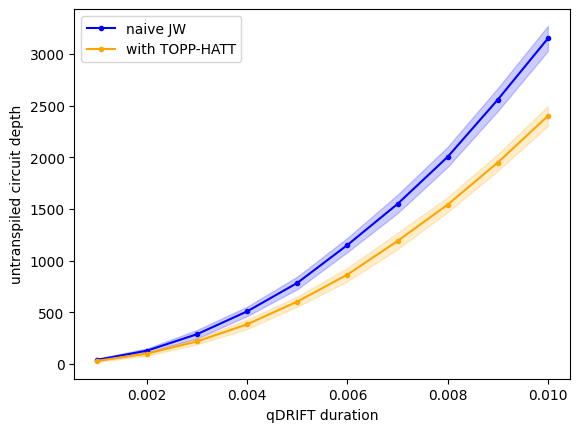

In [36]:
naive_edge = 'blue'
naive_fill = 'cornflowerblue'
tophatt_edge = 'orange'
tophatt_fill = 'moccasin'

plt.tight_layout()

plt.plot(depths, JW_mean_depths, '-', label='naive JW', color=naive_edge, marker='.')
plt.plot(depths, TH_mean_depths, '-', label='with TOPP-HATT', color=tophatt_edge, marker='.')

plt.fill_between(
    depths,
    np.array(JW_mean_depths) - np.array(JW_std_depths),
    np.array(JW_mean_depths) + np.array(JW_std_depths),
    alpha=0.2,
    color=naive_edge
)

plt.fill_between(
    depths,
    np.array(TH_mean_depths) - np.array(TH_std_depths),
    np.array(TH_mean_depths) + np.array(TH_std_depths),
    alpha=0.2,
    color=tophatt_edge
)

plt.xlabel('qDRIFT duration')
plt.ylabel('untranspiled circuit depth')

# plt.yscale('log')

plt.legend()

plt.savefig("qdrift_depths_scan.pdf")

plt.show()